# Data Exploration

In [ ]:
# Install huggingface datasets
# !pip install datasets

# Import Libraries

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Load dataset

In [8]:
# Load dataset
print("Loading dataset from Hugging Face...")
datasets = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")

print(datasets)

# Convert to pandas for easier exploration
df = pd.DataFrame(datasets['train'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading dataset from Hugging Face...


Generating train split: 100%|██████████| 26872/26872 [00:01<00:00, 15957.72 examples/s]


DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})
Dataset loaded successfully!
Shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


In [13]:
# First look at the data
df.head(10)

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...
5,BI,can you help me cancel order {{Order Number}}?,ORDER,cancel_order,"Of course, I'm here to assist you in canceling..."
6,BCLN,"I can no longer afford order {{Order Number}},...",ORDER,cancel_order,I pick up what you're putting down that you're...
7,BL,I am trying to cancel purchase {{Order Number}},ORDER,cancel_order,I've understood that you're seeking assistance...
8,BL,I have got to cancel purchase {{Order Number}},ORDER,cancel_order,I'm sensitive to the fact that you're seeking ...
9,BLQ,i need help canceling purchase {{Order Number}},ORDER,cancel_order,I perceive that you're seeking assistance with...


# Understand the Structure


In [14]:
# Dataset overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Total samples: {len(df):,}")
print(f"\n Columns and types:")
print(df.dtypes)

print(f"\n Missing values:")
print(df.isnull().sum())

print(f"\n Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW
Total samples: 26,872

 Columns and types:
flags          str
instruction    str
category       str
intent         str
response       str
dtype: object

 Missing values:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

 Memory usage: 19.13 MB


## Examine the columns

In [17]:
# Let's see what each column contains
for col in df.columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"{'='*60}")
    print(f"First sample: {df[col].iloc[0]}")  # Show first example
    print(f"\nUnique values: {df[col].nunique()}")


Column: flags
First sample: B

Unique values: 394

Column: instruction
First sample: question about cancelling order {{Order Number}}

Unique values: 24635

Column: category
First sample: ORDER

Unique values: 11

Column: intent
First sample: cancel_order

Unique values: 27

Column: response
First sample: I've understood you have a question regarding canceling order {{Order Number}}, and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.

Unique values: 26870


## Category Analysis

CATEGORY DISTRIBUTION

Total categories: 11
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


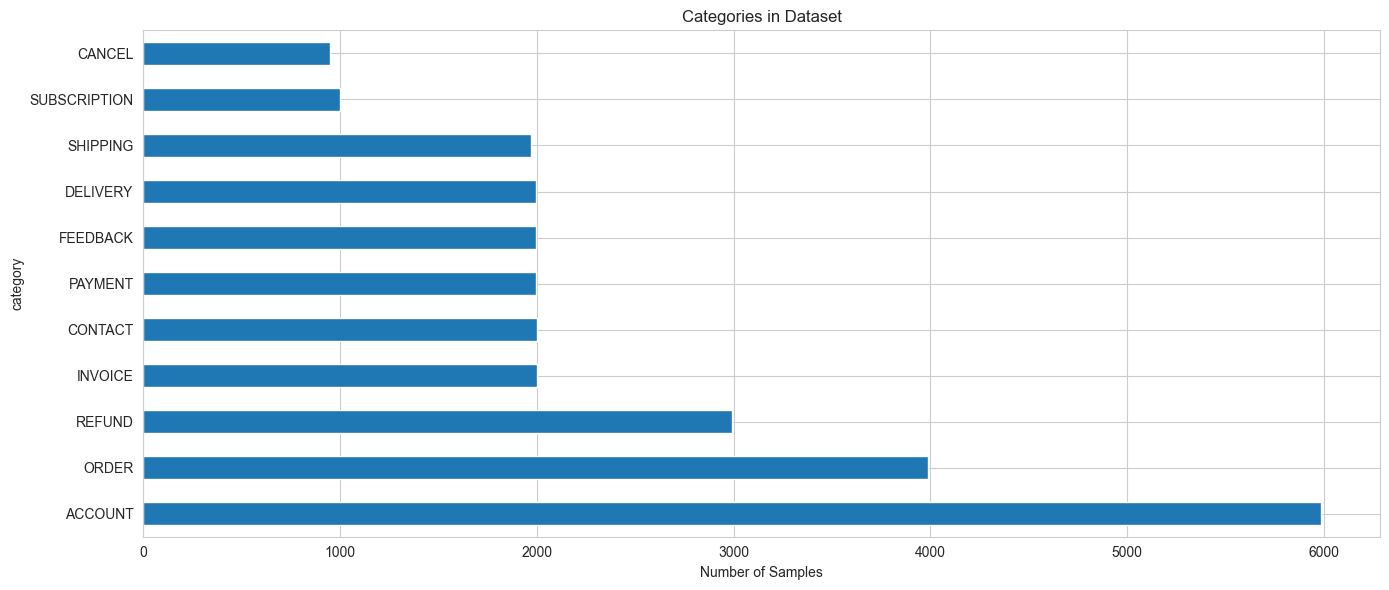

In [24]:
# What categories do we have?
print("CATEGORY DISTRIBUTION")
print("=" * 60)

# Count categories
category_counts = df['category'].value_counts()
print(f"\nTotal categories: {len(category_counts)}")
print(category_counts.head(len(category_counts)))

# Visualize
plt.figure(figsize=(14, 6))
category_counts.plot(kind='barh')
plt.xlabel('Number of Samples')
plt.title('Categories in Dataset')
plt.tight_layout()
plt.show()

## Category distribution (pie chart for top categories)

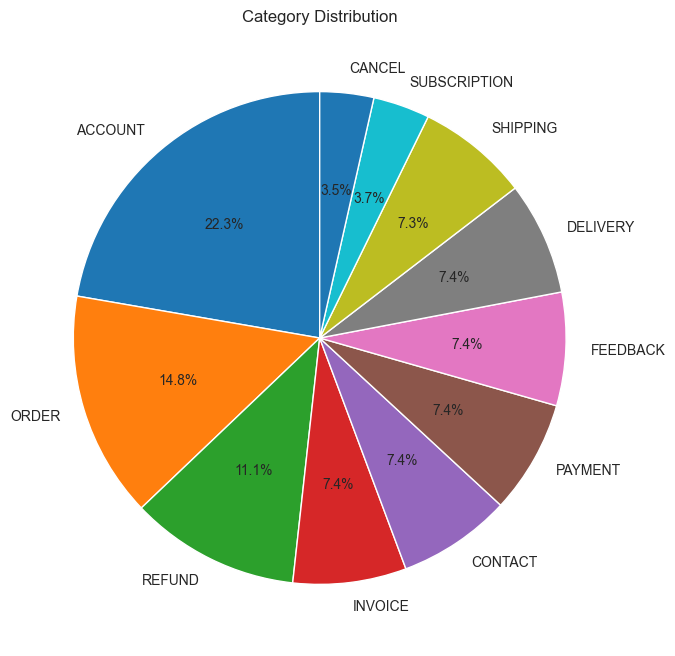

In [29]:

plt.figure(figsize=(12, 8))

plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Category Distribution')
plt.show()

# Text Analysis


 TEXT LENGTH STATISTICS

Instruction (Customer Query):
count    26872.000000
mean        46.889513
std         10.897578
min          6.000000
25%         40.000000
50%         48.000000
75%         55.000000
max         92.000000
Name: instruction_length, dtype: float64

Response (Agent Reply):
count    26872.000000
mean       634.104495
std        331.593822
min         57.000000
25%        427.000000
50%        540.000000
75%        753.000000
max       2472.000000
Name: response_length, dtype: float64


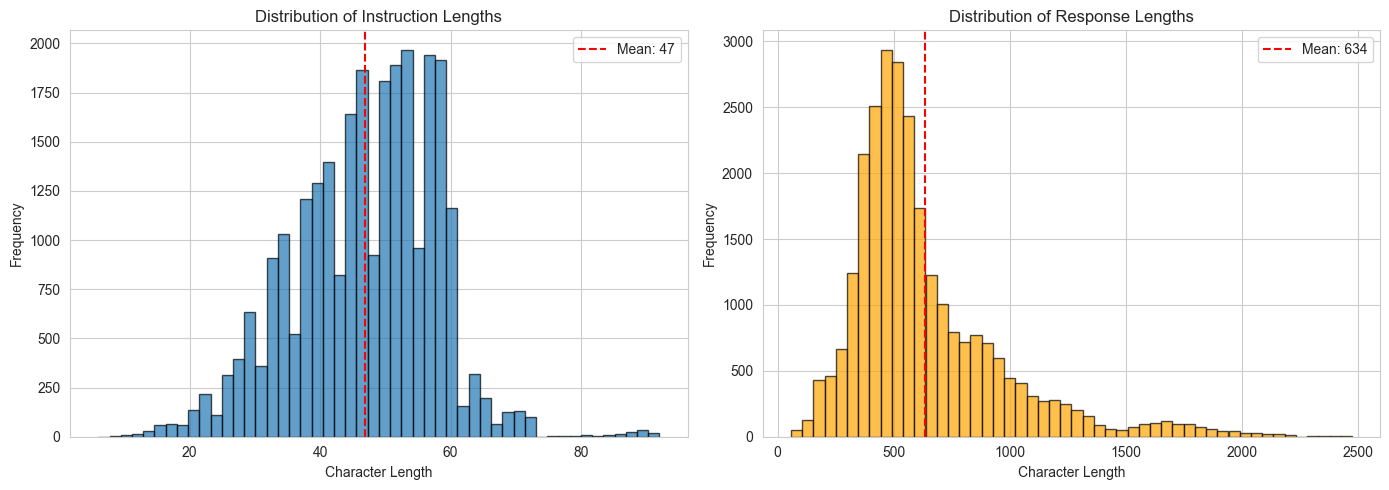

In [32]:
# Analyze text lengths
df['instruction_length'] = df['instruction'].str.len()
df['response_length'] = df['response'].str.len()

print(" TEXT LENGTH STATISTICS")
print("=" * 60)

print("\nInstruction (Customer Query):")
print(df['instruction_length'].describe())

print("\nResponse (Agent Reply):")
print(df['response_length'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['instruction_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Instruction Lengths')
axes[0].axvline(df['instruction_length'].mean(), color='red', 
                linestyle='--', label=f'Mean: {df["instruction_length"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['response_length'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Response Lengths')
axes[1].axvline(df['response_length'].mean(), color='red', 
                linestyle='--', label=f'Mean: {df["response_length"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Word count analysis

In [33]:
df['instruction_word_count'] = df['instruction'].str.split().str.len()
df['response_word_count'] = df['response'].str.split().str.len()

print("WORD COUNT STATISTICS")
print("=" * 60)
print("\nInstruction word count:")
print(df['instruction_word_count'].describe())

print("\nResponse word count:")
print(df['response_word_count'].describe())

WORD COUNT STATISTICS

Instruction word count:
count    26872.000000
mean         8.690979
std          2.605004
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         16.000000
Name: instruction_word_count, dtype: float64

Response word count:
count    26872.000000
mean       104.789037
std         52.966204
min          9.000000
25%         72.000000
50%         90.000000
75%        124.000000
max        402.000000
Name: response_word_count, dtype: float64


## Check for class imbalance

In [34]:
print("CLASS BALANCE ANALYSIS")
print("=" * 60)

# Calculate balance metrics
category_percentages = (category_counts / len(df) * 100).round(2)

print(f"\nMost common category: {category_counts.index[0]} ({category_percentages.iloc[0]}%)")
print(f"Least common category: {category_counts.index[-1]} ({category_percentages.iloc[-1]}%)")

# Check if we have severe imbalance (less than 1% for any category)
severe_imbalance = category_percentages[category_percentages < 1.0]
if len(severe_imbalance) > 0:
    print(f"\n⚠️  Warning: {len(severe_imbalance)} categories have less than 1% of data")
    print("These categories might need special handling (oversampling, class weights, etc.)")
else:
    print("\n✅ No severe class imbalance detected")

# Imbalance ratio
imbalance_ratio = category_counts.max() / category_counts.min()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}x")
if imbalance_ratio > 10:
    print("⚠️  High imbalance - consider techniques like SMOTE or class weights")

CLASS BALANCE ANALYSIS

Most common category: ACCOUNT (22.28%)
Least common category: CANCEL (3.54%)

✅ No severe class imbalance detected

Imbalance ratio: 6.30x


## Save cleaned data for next phase

In [ ]:
# Create a clean version with useful columns
df_clean = df[['instruction', 'response', 'category', 'intent']].copy()

# Save to CSV
df_clean.to_csv('../data/customer_support_clean.csv', index=False)
print("Cleaned data saved to: data/customer_support_clean.csv")

# Also save some metadata
metadata = {
    'total_samples': len(df),
    'num_categories': df['category'].nunique(),
    'avg_instruction_length': df['instruction_length'].mean(),
    'avg_response_length': df['response_length'].mean(),
    'most_common_category': category_counts.index[0],
    'imbalance_ratio': imbalance_ratio
}

import json
with open('../data/dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved to: data/dataset_metadata.json")